---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz H.
---

# 📉 Frontera Eficiente y el Efecto de la Diversificación

En este notebook construiremos y analizaremos portafolios de inversión compuestos por varias acciones, con dos objetivos centrales:

* **Ilustrar el efecto de la diversificación:** mostrar cómo la combinación de activos cuyos retornos no están perfectamente correlacionados puede reducir el riesgo total de una cartera sin disminuir necesariamente su retorno esperado.
* **Construir la Frontera Eficiente:** identificar el conjunto de portafolios que ofrecen el mayor retorno esperado para cada nivel de riesgo o, de manera equivalente, el menor riesgo posible para cada nivel de retorno esperado.

Para lograrlo:

1. Descargaremos precios históricos de cinco acciones —AAPL, WMT, INTC, XOM y LMT— y calcularemos sus retornos logarítmicos diarios.
2. Estimaremos el vector de retornos medios y la matriz de varianzas-covarianzas de estos activos.
3. Simularemos, mediante el método de **[Monte Carlo](https://www.ibm.com/es-es/think/topics/monte-carlo-simulation)**, miles de portafolios con ponderaciones aleatorias, calculando para cada uno su retorno esperado, volatilidad y ratio de Sharpe.
4. Identificaremos dos portafolios de referencia:

   * el portafolio de **mínima varianza global**, es decir, el de menor riesgo entre todos los portafolios factibles;
   * el Portfolio de Tangencia, es decir, el que presenta el mayor ratio de Sharpe respecto de la tasa libre de riesgo utilizada.
5. Representaremos los portafolios simulados en el plano riesgo-retorno, trazaremos la Frontera Eficiente y destacaremos ambos portafolios de referencia.

> 💡 **Idea central:** el riesgo de un portafolio no es simplemente el promedio ponderado del riesgo de sus activos individuales. También depende de las covarianzas entre sus retornos, es decir, de la forma en que los activos se mueven conjuntamente. Por esta razón, una combinación adecuada de activos puede reducir significativamente el riesgo total de la cartera y, en algunos casos, situarlo por debajo del riesgo de cualquiera de sus componentes individuales.

<a href="https://www.ibm.com/es-es/think/topics/monte-carlo-simulation" target="_blank">
  <img src="https://commons.wikimedia.org/wiki/Special:Redirect/file/IBM_logo.svg" alt="IBM: simulación de Monte Carlo" width="110">
</a>

*Haz clic en el logotipo para acceder a la explicación de IBM sobre la simulación de Monte Carlo.*

## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **Python** que utilizaremos a lo largo del notebook:

* **`yfinance`**: descarga de datos financieros desde Yahoo Finance.
* **`pandas`**: transformación y organización de datos.
* **`numpy`**: cálculos numéricos (álgebra matricial, retornos logarítmicos, simulación, etc.).
* **`matplotlib`**: construcción de gráficos.

> 💡 Las librerías deben instalarse una sola vez, pero deben importarse cada vez que se inicia una nueva sesión de Python.

In [1]:
%%capture
%pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display, Markdown

## 📥 Extracción de datos bursátiles

A continuación, descargaremos información histórica de precios para las siguientes acciones:

* **Apple Inc. (`AAPL`)**: empresa tecnológica.
* **Walmart Inc. (`WMT`)**: empresa del sector comercio minorista.
* **Intel Corporation (`INTC`)**: empresa de semiconductores.
* **Exxon Mobil Corporation (`XOM`)**: empresa del sector energético.
* **Lockheed Martin Corporation (`LMT`)**: empresa de los sectores aeroespacial y defensa.

Estas acciones pertenecen a industrias diferentes, lo que permitirá ilustrar cómo la diversificación entre sectores puede contribuir a reducir el riesgo total de un portafolio.

> 💡 Utilizaremos los precios ajustados, ya que incorporan el efecto de dividendos y divisiones de acciones, y permiten calcular retornos históricos de manera más consistente.

### 🏷️ Definiendo los *tickers* de las acciones

Primero, crearemos un objeto llamado `tick` que contendrá los símbolos bursátiles de las cinco acciones seleccionadas:

```python
tick = ["AAPL", "WMT", "INTC", "XOM", "LMT"]
```

En **Python**, los corchetes `[...]` permiten construir una lista con varios elementos.

Cada elemento del objeto `tick` corresponde al símbolo utilizado por Yahoo Finance para identificar una acción:

* `AAPL`: Apple Inc.
* `WMT`: Walmart Inc.
* `INTC`: Intel Corporation.
* `XOM`: Exxon Mobil Corporation.
* `LMT`: Lockheed Martin Corporation.

Esta lista será utilizada posteriormente en `yf.download()` para descargar simultáneamente los precios históricos de las cinco acciones.

> 💡 El nombre del objeto puede ser cualquiera, pero utilizaremos `tick` como una abreviación de *tickers*.

In [3]:
tick = ['AAPL', 'WMT', 'INTC', 'XOM', 'LMT']
tick

['AAPL', 'WMT', 'INTC', 'XOM', 'LMT']

In [4]:
tick
len(tick)

5

### 📥 Descarga de precios históricos

Como vimos en la clase anterior, **Riesgo y Retorno**, el paquete `yfinance` permite descargar datos financieros directamente desde Yahoo Finance y almacenarlos en un `pandas.DataFrame`.

En particular, la función `yf.download()` se utiliza para descargar información financiera para uno o varios símbolos bursátiles simultáneamente.

A continuación, descargaremos los precios históricos de las cinco acciones seleccionadas para el período **2021-2025**. Los datos obtenidos serán almacenados en el objeto `price_data`.

Para ello, utilizaremos:

* `tick`: lista que contiene los símbolos bursátiles de las acciones;
* `start`: fecha de inicio del período;
* `end`: fecha final del período.

> 💡 Vamos a descargar 5 años de datos. Por defecto, `yfinance` entrega los precios ya ajustados por dividendos y divisiones de acciones en la columna `Close`.

In [5]:
price_data = yf.download(tick, start='2021-01-01', end='2025-12-31', progress=False)['Close']
price_data = price_data[tick]
price_data

Ticker,AAPL,WMT,INTC,XOM,LMT
Date,,,,,
2021-01-04,125.740837,45.454304,44.902935,33.466637,296.881348
2021-01-05,127.295456,45.212349,45.752716,35.079483,300.456268
2021-01-06,123.010521,45.494629,46.195694,35.974613,299.801544
2021-01-07,127.208046,45.491520,47.181072,36.256866,295.081024
2021-01-08,128.306015,45.485329,46.692909,36.660080,289.524811
...,...,...,...,...,...
2025-12-23,271.854919,110.462059,36.349998,117.829521,476.898163
2025-12-24,273.302216,111.169258,36.160000,117.632195,480.060699
2025-12-26,272.893005,111.298744,36.200001,117.523659,477.372559


## 📈 Retornos diarios

A continuación, calcularemos los retornos diarios de las cinco acciones a partir de sus precios ajustados.

Utilizaremos **retornos logarítmicos**, definidos como:

$$r_{i,t}=\ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

donde:

* $P_{i,t}$ es el precio ajustado de la acción $i$ en el día $t$;
* $P_{i,t-1}$ es su precio ajustado en el día bursátil anterior;
* $r_{i,t}$ es el retorno logarítmico diario.

Los retornos logarítmicos son especialmente útiles porque pueden sumarse a través del tiempo. Por ejemplo, el retorno logarítmico acumulado durante varios días corresponde a la suma de los retornos diarios del período.

La información obtenida será almacenada en el objeto `log_returns`, con una columna por acción y una fila por fecha.

> 💡 El primer retorno de cada acción será `NaN`, porque no existe un precio anterior dentro de la muestra con el cual calcular su variación.

In [6]:
log_returns = np.log(price_data / price_data.shift(1))

In [7]:
display(log_returns.head())
display(log_returns.tail())

Ticker,AAPL,WMT,INTC,XOM,LMT
Date,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.012288,-0.005337,0.018748,0.047067,0.011970
2021-01-06,-0.034241,0.006224,0.009635,0.025197,-0.002181
2021-01-07,0.033554,-0.000068,0.021106,0.007815,-0.015871
2021-01-08,0.008594,-0.000136,-0.010400,0.011060,-0.019009


Ticker,AAPL,WMT,INTC,XOM,LMT
Date,,,,,
2025-12-23,0.005117,-0.015213,-0.000550,0.010692,-0.002112
2025-12-24,0.005310,0.006382,-0.005241,-0.001676,0.006610
2025-12-26,-0.001498,0.001164,0.001106,-0.000923,-0.005615
2025-12-29,0.001316,0.007045,0.013173,0.011851,0.012018
2025-12-30,-0.002487,-0.005435,0.016762,0.003809,-0.001781


> 🧑‍💻 **Nota para programadores**
>
> A diferencia de **R** con `tidyquant`, donde primero se calculan los retornos en **formato largo** (`tq_transmute()` agrupando por `symbol`) y luego se transforman a **formato ancho** con `pivot_wider()`, `yf.download()` con varios símbolos ya entrega los precios directamente en **formato ancho**: una columna por acción, una fila por fecha.
>
> Por eso, en Python el cálculo de retornos logarítmicos se realiza en un solo paso, dividiendo directamente el `DataFrame` de precios por su versión rezagada un día (`price_data.shift(1)`), sin necesidad de un paso intermedio de transformación entre formatos largo y ancho.
>
> 💡 De todas formas, ambos formatos son igualmente válidos: el formato largo es preferible para agrupar y transformar series por separado, mientras que el formato ancho es el que necesitamos para calcular estadísticos conjuntos como varianzas y covarianzas.

Ahora sí tenemos los datos como los necesitamos.

---

# 📊 Estadísticos requeridos

Para construir los portafolios necesitamos estimar los retornos medios de los activos y la forma en que dichos retornos varían conjuntamente.

## 📈 Retorno logarítmico medio diario de cada activo

Como anteriormente calculamos los **retornos logarítmicos diarios**, obtendremos para cada acción el promedio simple de sus retornos observados:

$$\bar{r}_{i}=\frac{r_{i,1}+r_{i,2}+\cdots+r_{i,T}}{T}$$

donde:

* $r_{i,t}$ es el retorno logarítmico de la acción $i$ en el día $t$;
* $T$ es el número total de retornos diarios disponibles;
* $\bar{r}_i$ es el retorno logarítmico medio diario de la acción $i$.

En Python, este cálculo se realiza con:

```python
mean_ret = log_returns.mean()
print(mean_ret.round(5))
```

El método `.mean()` calcula el promedio de cada columna de `log_returns`. Como cada columna corresponde a una acción, el objeto `mean_ret` contiene el retorno logarítmico medio diario de cada activo.

> ⚠️ Estos valores son promedios históricos calculados a partir de la muestra y no garantizan los retornos futuros.

In [8]:
mean_ret = log_returns.mean()
print(mean_ret.round(5))

Ticker
AAPL    0.00062
WMT     0.00072
INTC   -0.00015
XOM     0.00101
LMT     0.00039
dtype: float64


## 🧮 Varianzas y covarianzas

Para construir los portafolios necesitamos conocer no solo el riesgo individual de cada acción, sino también la manera en que sus retornos se mueven conjuntamente.

La **varianza** mide la dispersión de los retornos de un activo alrededor de su promedio. Para el activo $i$, la varianza muestral se calcula como:

$$s_{i}^{2}=\frac{\left(r_{i,1}-\bar{r}_{i}\right)^{2}+\left(r_{i,2}-\bar{r}_{i}\right)^{2}+\cdots+\left(r_{i,T}-\bar{r}_{i}\right)^{2}}{T-1}$$

donde:

* $r_{i,t}$ es el retorno del activo $i$ en el período $t$;
* $\bar{r}_{i}$ es el retorno medio del activo $i$;
* $T$ es el número de observaciones;
* $s_{i}^{2}$ es la varianza muestral del activo.

La **covarianza** entre dos activos mide la manera en que sus retornos se mueven conjuntamente. Para los activos $i$ y $j$, se calcula como:

$$s_{ij}=\frac{\left(r_{i,1}-\bar{r}_{i}\right)\left(r_{j,1}-\bar{r}_{j}\right)+\cdots+\left(r_{i,T}-\bar{r}_{i}\right)\left(r_{j,T}-\bar{r}_{j}\right)}{T-1}$$

donde:

* $r_{i,t}$ es el retorno del activo $i$ en el período $t$;
* $r_{j,t}$ es el retorno del activo $j$ en el período $t$;
* $\bar{r}_{i}$ y $\bar{r}_{j}$ son los retornos medios de ambos activos;
* $T$ es el número de observaciones;
* $s_{ij}$ es la covarianza muestral entre los activos $i$ y $j$.

La interpretación de la covarianza es la siguiente:

* una covarianza positiva indica que ambos activos tienden a moverse en la misma dirección;
* una covarianza negativa indica que tienden a moverse en direcciones opuestas;
* una covarianza cercana a cero indica que no presentan una relación lineal importante.

En la matriz de varianzas y covarianzas:

* las **varianzas** aparecen en la diagonal principal;
* las **covarianzas** aparecen fuera de la diagonal.

A continuación, calcularemos la matriz diaria de varianzas y covarianzas de los retornos logarítmicos y la anualizaremos multiplicando cada elemento por 252.

```python
cov_mat = log_returns.cov() * 252
print(cov_mat.round(4))
```

In [9]:
cov_mat = log_returns.cov() * 252

print(cov_mat.round(4))

Ticker    AAPL     WMT    INTC     XOM     LMT
Ticker                                        
AAPL    0.0771  0.0166  0.0483  0.0143  0.0065
WMT     0.0166  0.0439  0.0118  0.0071  0.0075
INTC    0.0483  0.0118  0.2150  0.0223  0.0059
XOM     0.0143  0.0071  0.0223  0.0732  0.0153
LMT     0.0065  0.0075  0.0059  0.0153  0.0485


---

# 💼 Construcción y evaluación de un portafolio individual

Antes de analizar miles de combinaciones posibles, comenzaremos con un solo portafolio. El objetivo es ilustrar, paso a paso, cómo se calculan su retorno esperado y su riesgo.

Posteriormente, generalizaremos este procedimiento mediante una simulación de Monte Carlo, construyendo una gran cantidad de portafolios con diferentes ponderaciones.

Para evaluar un portafolio necesitamos tres elementos:

* el vector de retornos medios de los activos;
* el vector de ponderaciones del portafolio;
* la matriz de varianzas y covarianzas de los activos.

## ⚖️ Ponderaciones del portafolio

Las ponderaciones indican qué proporción de la riqueza total se invierte en cada activo.

Si el portafolio está completamente invertido, las ponderaciones deben sumar uno:

$$w_{1}+w_{2}+\cdots+w_{N}=1$$

El vector de ponderaciones se representa como:

$$W=\begin{bmatrix}w_{1}\\w_{2}\\\vdots\\w_{N}\end{bmatrix}$$

donde $w_{i}$ representa la proporción invertida en el activo $i$.

## 📈 Retorno esperado del portafolio

El retorno esperado del portafolio corresponde al promedio ponderado de los retornos esperados de los activos:

$$E\left[\widetilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}E\left[\widetilde{r}_{i}\right]$$

Definimos el vector de retornos medios como:

$$R=\begin{bmatrix}E\left[\widetilde{r}_{1}\right]\\E\left[\widetilde{r}_{2}\right]\\\vdots\\E\left[\widetilde{r}_{N}\right]\end{bmatrix}$$

En forma matricial, el retorno esperado del portafolio se obtiene como:

$$E\left[\widetilde{r}_{p}\right]=\begin{bmatrix}E\left[\widetilde{r}_{1}\right]&E\left[\widetilde{r}_{2}\right]&\cdots&E\left[\widetilde{r}_{N}\right]\end{bmatrix}\begin{bmatrix}w_{1}\\w_{2}\\\vdots\\w_{N}\end{bmatrix}=R^{\prime}W$$

Por lo tanto, el retorno esperado del portafolio depende linealmente de las ponderaciones asignadas a cada activo.

## 📉 Varianza del portafolio

La varianza del portafolio incorpora tanto las varianzas individuales como las covarianzas entre los activos:

$$\operatorname{Var}\left[\widetilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}^{2}\sigma_{ii}+\sum_{i=1}^{N}\sum_{\substack{j=1\\j\neq i}}^{N}w_{i}w_{j}\sigma_{ij}$$

De manera equivalente:

$$\operatorname{Var}\left[\widetilde{r}_{p}\right]=\sum_{i=1}^{N}\sum_{j=1}^{N}w_{i}w_{j}\sigma_{ij}$$

La matriz de varianzas y covarianzas se representa como:

$$\Sigma=\begin{bmatrix}\sigma_{11}&\sigma_{12}&\cdots&\sigma_{1N}\\\sigma_{21}&\sigma_{22}&\cdots&\sigma_{2N}\\\vdots&\vdots&\ddots&\vdots\\\sigma_{N1}&\sigma_{N2}&\cdots&\sigma_{NN}\end{bmatrix}$$

En forma matricial, la varianza del portafolio se obtiene como:

$$\operatorname{Var}\left[\widetilde{r}_{p}\right]=\begin{bmatrix}w_{1}&w_{2}&\cdots&w_{N}\end{bmatrix}\begin{bmatrix}\sigma_{11}&\sigma_{12}&\cdots&\sigma_{1N}\\\sigma_{21}&\sigma_{22}&\cdots&\sigma_{2N}\\\vdots&\vdots&\ddots&\vdots\\\sigma_{N1}&\sigma_{N2}&\cdots&\sigma_{NN}\end{bmatrix}\begin{bmatrix}w_{1}\\w_{2}\\\vdots\\w_{N}\end{bmatrix}=W^{\prime}\Sigma W$$

La desviación estándar, que utilizaremos como medida del riesgo del portafolio, es:

$$\sigma_{p}=\sqrt{W^{\prime}\Sigma W}$$

donde:

* $W$ es el vector de ponderaciones;
* $R$ es el vector de retornos medios;
* $\Sigma$ es la matriz de varianzas y covarianzas;
* $E\left[\widetilde{r}_{p}\right]$ es el retorno esperado del portafolio;
* $\sigma_{p}$ es la volatilidad del portafolio.

## 📅 Anualización

Como los retornos medios fueron estimados con datos diarios, el retorno esperado anualizado se obtiene aproximadamente como:

$$E\left[\widetilde{r}_{p,\text{anual}}\right]=252R^{\prime}W$$

Como la matriz $\Sigma$ ya fue anualizada multiplicando la matriz diaria por 252, el riesgo anualizado se calcula directamente como:

$$\sigma_{p,\text{anual}}=\sqrt{W^{\prime}\Sigma W}$$

> 💡 **Idea central:** el retorno del portafolio es un promedio ponderado de los retornos de los activos. Su riesgo, en cambio, depende tanto de las varianzas individuales como de las covarianzas entre los activos. Por ello, una combinación adecuada de ponderaciones puede reducir el riesgo total mediante diversificación.

### 🧮 Ejemplo numérico: un portafolio de dos activos

Para fijar ideas, apliquemos las fórmulas anteriores a un caso simple: un portafolio compuesto por solo dos activos —los dos primeros de la lista `tick`— con ponderaciones ilustrativas de 60% y 40%.

Seleccionamos los activos **por posición** (`tick[0]` y `tick[1]`) en lugar de escribir sus símbolos ("AAPL", "WMT", etc.) directamente en el código. Así, si en el futuro cambiamos la composición de `tick` (agregando, quitando o reordenando acciones), este ejemplo seguirá funcionando sin modificaciones.

Además, en lugar de escribir los valores numéricos "a mano", extraeremos directamente los retornos medios y la matriz de varianzas-covarianzas ya calculados (`mean_ret` y `cov_mat`). De esta manera, si este notebook se vuelve a ejecutar más adelante con datos actualizados, las cifras del ejemplo se actualizarán automáticamente.

Para que la notación matricial quede clara, construiremos explícitamente los objetos $W$, $R$ y $\Sigma$ como matrices de **NumPy**, y calcularemos paso a paso $R'W$ y $W'\Sigma W$ antes de anualizar los resultados.

In [10]:
# Dos activos, seleccionados por posición (no por símbolo)
# para que el ejemplo siga funcionando si más adelante cambia la composición de "tick"
activos_ejemplo = tick[0:2]
w_ejemplo = np.array([0.6, 0.4])  # ponderaciones ilustrativas; deben sumar 1

# Construimos W, R y Sigma como matrices explícitas
W = w_ejemplo.reshape(-1, 1)
R = mean_ret[activos_ejemplo].to_numpy().reshape(-1, 1)
Sigma = cov_mat.loc[activos_ejemplo, activos_ejemplo].to_numpy()

print("Vector de ponderaciones W:")
print(pd.DataFrame(W, index=activos_ejemplo, columns=["w"]))

print("\nVector de retornos medios diarios R:")
print(pd.DataFrame(R.round(5), index=activos_ejemplo, columns=["E[r]"]))

print("\nMatriz de varianzas-covarianzas anualizada Σ:")
print(pd.DataFrame(Sigma.round(4), index=activos_ejemplo, columns=activos_ejemplo))

# Función auxiliar: convierte una matriz/vector numérico a notación LaTeX (bmatrix)
def mat_to_latex(m, digits=4):
    m = np.round(np.atleast_2d(m), digits)
    filas = [" & ".join(map(str, fila)) for fila in m]
    return "\\\\begin{bmatrix}\n" + " \\\\\\\\\n".join(filas) + "\n\\\\end{bmatrix}"

# R'W, en notación matricial y con los valores reales del ejemplo
retorno_diario = (R.T @ W).item()
display(Markdown(
    f"$$\n{mat_to_latex(R.T, 5)}\n{mat_to_latex(W, 1)}"
    f" = {round(retorno_diario, 5)}\n$$"
))

retorno_anual = 252 * retorno_diario
print(f"Retorno esperado del portafolio (anualizado) = {retorno_anual * 100:.2f}%")

# W'ΣW, en notación matricial y con los valores reales del ejemplo
varianza_anual = (W.T @ Sigma @ W).item()
display(Markdown(
    f"$$\n{mat_to_latex(W.T, 1)}\n{mat_to_latex(Sigma, 4)}\n{mat_to_latex(W, 1)}"
    f" = {round(varianza_anual, 4)}\n$$"
))

riesgo_anual = np.sqrt(varianza_anual)
print(f"Riesgo (desviación estándar) anualizado      = {riesgo_anual * 100:.2f}%")

Vector de ponderaciones W:
        w
AAPL  0.6
WMT   0.4

Vector de retornos medios diarios R:
         E[r]
AAPL  0.00062
WMT   0.00072

Matriz de varianzas-covarianzas anualizada Σ:
        AAPL     WMT
AAPL  0.0771  0.0166
WMT   0.0166  0.0439


$$
\\begin{bmatrix}
0.00062 & 0.00072
\\end{bmatrix}
\\begin{bmatrix}
0.6 \\\\
0.4
\\end{bmatrix} = 0.00066
$$

Retorno esperado del portafolio (anualizado) = 16.55%


$$
\\begin{bmatrix}
0.6 & 0.4
\\end{bmatrix}
\\begin{bmatrix}
0.0771 & 0.0166 \\\\
0.0166 & 0.0439
\\end{bmatrix}
\\begin{bmatrix}
0.6 \\\\
0.4
\\end{bmatrix} = 0.0428
$$

Riesgo (desviación estándar) anualizado      = 20.69%


## 🎲 Ponderaciones aleatorias

Para construir nuestro primer portafolio, generaremos una ponderación aleatoria para cada uno de los activos.

La función `np.random.uniform()` genera números aleatorios provenientes de una distribución uniforme. Esto significa que todos los valores comprendidos en el intervalo especificado tienen la misma probabilidad de ser seleccionados.

Por ejemplo, la siguiente instrucción genera cinco números aleatorios entre 0 y 1:

```python
np.random.uniform(0, 1, 5)
```

Sin embargo, estos valores iniciales no necesariamente suman uno. Como las ponderaciones de un portafolio completamente invertido deben cumplir:

$$w_{1}+w_{2}+\cdots+w_{N}=1$$

debemos normalizar los números aleatorios generados. Para ello, dividimos cada valor por la suma de todos los valores:

$$w_{i}=\frac{x_{i}}{\sum_{j=1}^{N}x_{j}}$$

donde:

* $x_{i}$ es el número aleatorio inicialmente asignado al activo $i$;
* $w_{i}$ es la ponderación normalizada del activo $i$;
* $N$ es el número total de activos.

De esta manera, todas las ponderaciones quedan comprendidas entre 0 y 1 y su suma es exactamente igual a uno.

> 💡 Como `np.random.uniform()` genera valores no negativos, este procedimiento produce un portafolio sin ventas cortas.

In [11]:
wts = np.random.uniform(0, 1, len(tick))
print(wts)
print(wts.sum())
wts = wts / wts.sum()
print(wts)
print(wts.sum())

[0.69559235 0.66505043 0.3571249  0.30632028 0.7510182 ]
2.7751061507375274
[0.25065432 0.23964865 0.12868873 0.11038146 0.27062684]
1.0


## 📊 Retorno y Riesgo del Portfolio

Utilizando las ponderaciones almacenadas en `wts`, calcularemos el retorno esperado y el riesgo anualizados de nuestro portafolio.

Primero, obtenemos el retorno medio diario ponderado:

$$\bar{r}_{p}=\sum_{i=1}^{N}w_{i}\bar{r}_{i}$$

Luego, el código transforma este retorno diario en un retorno anual equivalente, suponiendo 252 días bursátiles:

$$\bar{r}_{p,\text{anual}}=\left(1+\bar{r}_{p}\right)^{252}-1$$

El riesgo del portafolio se mide mediante su desviación estándar anualizada:

$$\sigma_{p}=\sqrt{W^{\prime}\Sigma W}$$

En esta expresión, $W$ es el vector de ponderaciones y $\Sigma$ es la matriz anualizada de varianzas y covarianzas.

> 💡 De esta manera, obtenemos dos medidas fundamentales para evaluar el portafolio: su retorno anual esperado y su volatilidad anual.

In [12]:
port_returns = (np.sum(wts * mean_ret) + 1)**252 - 1
print(port_returns)

port_risk = np.sqrt(wts @ cov_mat.to_numpy() @ wts)
print(port_risk)

0.14116089187554204
0.1618707445404994


## 🏆 Sharpe Ratio

El **Sharpe Ratio** mide el retorno adicional obtenido por un portafolio por cada unidad de riesgo asumida:

$$SR_{p}=\frac{E\left[\widetilde{r}_{p}\right]-r_{f}}{\sigma_{p}}$$

donde:

* $E\left[\widetilde{r}_{p}\right]$ es el retorno esperado anualizado del portafolio;
* $r_{f}$ es la tasa libre de riesgo anual;
* $\sigma_{p}$ es la desviación estándar anualizada del portafolio.

El numerador representa el **exceso de retorno** del portafolio respecto de la tasa libre de riesgo:

$$E\left[\widetilde{r}_{p}\right]-r_{f}$$

### 🏛️ Tasa libre de riesgo

Como referencia general para consultar y comparar rendimientos de bonos soberanos de distintos países, puedes visitar:

<p align="center">
  <a href="http://www.worldgovernmentbonds.com/" target="_blank">
    <img src="https://www.worldgovernmentbonds.com/wp-content/uploads/2023/10/logo.png" alt="World Government Bonds" style="height: 2.2em !important; width: auto !important; max-width: none !important;"/>
  </a>
</p>

Sin embargo, tal como hicimos en la unidad anterior (**Riesgo-Retorno**), en este notebook obtendremos la tasa libre de riesgo **directamente desde el código**, en lugar de copiarla manualmente desde un sitio web. Para ello utilizaremos [FRED](https://fred.stlouisfed.org/) (*Federal Reserve Economic Data*), la base de datos pública del Banco de la Reserva Federal de St. Louis, que publica el rendimiento de los bonos del Tesoro de Estados Unidos para distintos plazos:

| Instrumento        |   Código |
| ------------------ | -------: |
| Treasury a 3 meses | `DGS3MO` |
| Treasury a 1 año   |   `DGS1` |
| Treasury a 2 años  |   `DGS2` |
| Treasury a 5 años  |   `DGS5` |
| Treasury a 10 años |  `DGS10` |
| Treasury a 30 años |  `DGS30` |

Puedes reemplazar el código utilizado en el ejemplo por cualquiera de estos para obtener la tasa libre de riesgo a un plazo distinto. En este ejercicio utilizaremos `DGS10` (Treasury a 10 años), consistente con el plazo utilizado en la unidad anterior. La tasa se publica en puntos porcentuales, por lo que debemos dividirla por 100 antes de incorporarla a los cálculos.

La interpretación del Sharpe Ratio es directa:

* un valor más alto indica una mejor relación entre retorno y riesgo;
* un valor igual a cero indica que el portafolio ofrece el mismo retorno que el activo libre de riesgo;
* un valor negativo indica que el portafolio presenta un retorno inferior a la tasa libre de riesgo.

> 💡 Para que el Sharpe Ratio sea consistente, el retorno esperado del portafolio, la tasa libre de riesgo y la desviación estándar deben estar expresados en la misma frecuencia. En este caso, todas las variables estarán anualizadas.

In [13]:
# Tasa libre de riesgo: Treasury a 10 años, obtenida directamente desde FRED
rf_data = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10")
rf_data = rf_data.dropna(subset=["DGS10"])

rf = rf_data["DGS10"].iloc[-1] / 100  # última tasa disponible, convertida a decimal
print(f"Tasa libre de riesgo (Treasury 10 años, FRED DGS10, {rf_data['observation_date'].iloc[-1]}): {rf * 100:.2f}%")

sharpe_ratio = (port_returns - rf) / port_risk
print(f"Sharpe Ratio del portafolio es: {sharpe_ratio:.4f}")

Tasa libre de riesgo (Treasury 10 años, FRED DGS10, 2026-07-16): 4.57%
Sharpe Ratio del portafolio es: 0.5897


### 🤔 ¿Es la tasa *spot* la mejor elección?

Utilizamos el último dato publicado de la serie (la tasa "spot" del día de la consulta). Sin embargo, cabe preguntarse si esta es la mejor opción para estimar $r_{f}$.

**A favor de usar la tasa más reciente:**

* Refleja las condiciones de mercado vigentes en el momento del análisis, es decir, el costo de oportunidad *actual* del capital.
* El Sharpe Ratio suele interpretarse de manera prospectiva (qué tan atractivo es el portafolio **hoy**), por lo que una tasa vigente es coherente con ese uso.

**A favor de usar un promedio (por ejemplo, de los últimos 12 meses):**

* Suaviza fluctuaciones de corto plazo o movimientos puntuales de la tasa, como los provocados por shocks de política monetaria.
* Es más consistente, metodológicamente, con el resto del ejercicio: el retorno y el riesgo del portafolio (`mean_ret`, `cov_mat`) se estiman como **promedios sobre varios años** de datos históricos, mientras que la tasa *spot* corresponde a un único punto en el tiempo. Existe, por lo tanto, un posible descalce de horizontes entre el numerador y el denominador del Sharpe Ratio.

> ⚠️ No existe una única respuesta "correcta": la elección depende de si el objetivo es evaluar el desempeño **histórico** del portafolio (lo que favorecería promediar la tasa sobre el mismo período) o su atractivo **actual** hacia adelante (lo que favorecería la tasa *spot*).

A continuación, comparamos ambas alternativas:

In [14]:
# Comparamos la tasa spot con el promedio de los últimos 12 meses
rf_data["observation_date"] = pd.to_datetime(rf_data["observation_date"])
fecha_corte = rf_data["observation_date"].iloc[-1] - pd.Timedelta(days=365)

rf_12m = rf_data.loc[rf_data["observation_date"] >= fecha_corte, "DGS10"].mean() / 100

print(f"Tasa spot ({rf_data['observation_date'].iloc[-1].date()}):            {rf * 100:.2f}%")
print(f"Promedio últimos 12 meses:      {rf_12m * 100:.2f}%")

sharpe_ratio_12m = (port_returns - rf_12m) / port_risk
print(f"\nSharpe Ratio (tasa spot):          {sharpe_ratio:.4f}")
print(f"Sharpe Ratio (promedio 12 meses):  {sharpe_ratio_12m:.4f}")

Tasa spot (2026-07-16):            4.57%
Promedio últimos 12 meses:      4.25%

Sharpe Ratio (tasa spot):          0.5897
Sharpe Ratio (promedio 12 meses):  0.6093


---

# 🔁 Simulación de $N$ portafolios

Una vez comprendido el cálculo del retorno, el riesgo y el Sharpe Ratio de un solo portafolio, generalizaremos el procedimiento mediante una simulación de Monte Carlo.

La idea consiste en generar una gran cantidad de portafolios, cada uno con una combinación diferente de ponderaciones aleatorias. Para cada portafolio calcularemos:

* el retorno anualizado;
* el riesgo anualizado;
* el Sharpe Ratio;
* las ponderaciones asignadas a cada activo.

Primero debemos definir el número de portafolios que deseamos simular. Representaremos este número mediante $N$:

$$N=\text{número de portafolios simulados}$$

También crearemos el objeto `all_wts`, que almacenará las ponderaciones de todos los portafolios generados.

Cada fila de `all_wts` representará un portafolio diferente y cada columna corresponderá a uno de los activos:

$$\text{all\_wts}=
\begin{bmatrix}
w_{1,1} & w_{1,2} & \cdots & w_{1,K} \\
w_{2,1} & w_{2,2} & \cdots & w_{2,K} \\
\vdots  & \vdots  & \ddots & \vdots  \\
w_{N,1} & w_{N,2} & \cdots & w_{N,K}
\end{bmatrix}$$

donde:

* $N$ es el número de portafolios simulados;
* $K$ es el número de activos;
* $w_{p,i}$ es la ponderación del activo $i$ en el portafolio $p$.

Para cada portafolio, las ponderaciones deberán cumplir:

$$\sum_{i=1}^{K}w_{p,i}=1$$

De esta manera, `all_wts` tendrá $N$ filas y $K$ columnas, permitiéndonos almacenar y analizar todas las combinaciones de ponderaciones generadas.

> 💡 Al aumentar el número de portafolios simulados, obtendremos una representación más completa del conjunto de combinaciones posibles de retorno y riesgo.

In [15]:
num_port = 100000
all_wts = np.zeros((num_port, len(tick)))

## 🗃️ Vectores para almacenar los resultados

Antes de iniciar la simulación, debemos crear tres vectores para almacenar los resultados obtenidos para cada portafolio:

* `port_returns`: almacenará el retorno anualizado de cada portafolio;
* `port_risk`: almacenará la desviación estándar anualizada de cada portafolio;
* `sharpe_ratio`: almacenará el Sharpe Ratio de cada portafolio.

Cada vector tendrá una longitud igual al número total de portafolios simulados:

$$\text{Longitud de cada vector}=N$$

En Python, podemos crear estos vectores de la siguiente manera:

```python
port_returns = np.zeros(num_port)
port_risk = np.zeros(num_port)
sharpe_ratio = np.zeros(num_port)
```

La función `np.zeros(N)` crea un arreglo numérico de longitud $N$, inicialmente compuesto por ceros.

Durante la simulación, la posición $p$ de cada vector almacenará el resultado correspondiente al portafolio $p$:

* la posición `port_returns[p]` almacenará su retorno anualizado;
* la posición `port_risk[p]` almacenará su riesgo anualizado;
* la posición `sharpe_ratio[p]` almacenará su Sharpe Ratio.

De esta manera, al finalizar la simulación tendremos organizados los resultados de todos los portafolios para analizarlos y representarlos gráficamente.

In [16]:
port_returns = np.zeros(num_port)
port_risk = np.zeros(num_port)
sharpe_ratio = np.zeros(num_port)

## 🔄 Simulación mediante un ciclo `for`

Ahora utilizaremos un ciclo `for` para repetir el procedimiento anterior tantas veces como portafolios deseamos simular.

El ciclo recorrerá todas las posiciones del arreglo `port_returns`:

```python
for i in range(num_port):

    ...
```

La función `range(num_port)` genera una secuencia desde 0 hasta `num_port - 1`. Por tanto, en cada iteración, `i` identifica el portafolio que se está construyendo.

Dentro del ciclo se realizan las siguientes operaciones:

* se generan ponderaciones aleatorias mediante `np.random.uniform()`;
* las ponderaciones se normalizan para que sumen uno;
* las ponderaciones se almacenan en la fila `i` de `all_wts`;
* se calcula el retorno anualizado del portafolio;
* se calcula su desviación estándar anualizada;
* se calcula su Sharpe Ratio utilizando la tasa libre de riesgo almacenada en `rf`.

La indexación permite guardar los resultados de cada portafolio en la posición correspondiente:

* `all_wts[i, :]` almacena las ponderaciones del portafolio `i`;
* `port_returns[i]` almacena su retorno anualizado;
* `port_risk[i]` almacena su riesgo anualizado;
* `sharpe_ratio[i]` almacena su Sharpe Ratio.

> 💡 Al finalizar el ciclo, todos los objetos contendrán la información de los portafolios simulados y podrán combinarse posteriormente en una sola base de datos para su análisis y representación gráfica.

In [17]:
mean_ret_arr = mean_ret.to_numpy()
cov_mat_arr = cov_mat.to_numpy()

for i in range(num_port):

    wts = np.random.uniform(0, 1, len(tick))
    wts = wts / wts.sum()

    # Storing weights in the matrix
    all_wts[i, :] = wts

    # Portfolio returns
    port_ret = np.sum(wts * mean_ret_arr)
    port_ret = (port_ret + 1)**252 - 1

    # Storing Portfolio Returns values
    port_returns[i] = port_ret

    # Creating and storing portfolio risk
    port_sd = np.sqrt(wts @ cov_mat_arr @ wts)
    port_risk[i] = port_sd

    # Creating and storing Portfolio Sharpe Ratios
    sr = (port_ret - rf) / port_sd
    sharpe_ratio[i] = sr

## 🧾 Almacenamiento de los resultados en un `DataFrame`

Una vez finalizada la simulación, reuniremos en una sola tabla los retornos, riesgos, Sharpe Ratios y ponderaciones de todos los portafolios.

El objeto `portfolio_values` contendrá una fila por cada portafolio simulado.

Las primeras columnas mostrarán:

* `Return`: retorno anualizado del portafolio;
* `Risk`: desviación estándar anualizada del portafolio;
* `SharpeRatio`: Sharpe Ratio del portafolio.

Las columnas restantes contendrán las ponderaciones asignadas a cada una de las acciones.

De esta manera, todos los resultados quedan organizados en una sola base de datos, lista para identificar portafolios relevantes y construir el gráfico de riesgo y retorno.

In [18]:
portfolio_values = pd.DataFrame({
    'Return': port_returns,
    'Risk': port_risk,
    'SharpeRatio': sharpe_ratio,
})

In [19]:
portfolio_values.head()

,Return,Risk,SharpeRatio
0,0.150536,0.186023,0.563564
1,0.134014,0.186874,0.472590
2,0.126379,0.162083,0.497760
3,0.159196,0.173275,0.655005
4,0.102993,0.221132,0.259089


### 🔗 Incorporación de las ponderaciones a la tabla

Ahora queremos agregar a la tabla `portfolio_values` las ponderaciones correspondientes a cada portafolio.

El arreglo `all_wts` contiene una fila por portafolio y una columna por activo. Antes de unirlo con `portfolio_values`, lo convertimos en un `DataFrame` y asignamos a sus columnas los nombres de las acciones:

```python
all_wts_df = pd.DataFrame(all_wts, columns=tick)
```

Luego, utilizamos `pd.concat()` para pegar las columnas de ponderaciones a la tabla que contiene los retornos, riesgos y Sharpe Ratios:

```python
portfolio_values = pd.concat([all_wts_df, portfolio_values], axis=1)
```

Como ambos objetos tienen el mismo número de filas, la fila `i` de `all_wts_df` se incorpora a la fila `i` de `portfolio_values`.

De esta forma, cada fila de `portfolio_values` contiene:

* el retorno anualizado del portafolio;
* su riesgo anualizado;
* su Sharpe Ratio;
* la ponderación asignada a cada activo.

Podemos comprobar el resultado mediante:

```python
portfolio_values.head()
```

> 💡 Es fundamental que `portfolio_values` y `all_wts_df` tengan el mismo número de filas para que las ponderaciones queden asociadas al portafolio correcto.

In [20]:
all_wts_df = pd.DataFrame(all_wts, columns=tick)

In [21]:
display(all_wts_df.head())
type(all_wts_df)

,AAPL,WMT,INTC,XOM,LMT
0,0.225945,0.478154,0.189911,0.098492,0.007497
1,0.076756,0.294811,0.266475,0.223035,0.138924
2,0.110406,0.264171,0.173537,0.104758,0.347128
3,0.245098,0.211885,0.156861,0.250165,0.135991
4,0.185743,0.301494,0.357987,0.082178,0.072599


pandas.core.frame.DataFrame

Finalmente, juntamos ambas tablas con **`pd.concat()`**

In [22]:
portfolio_values = pd.concat([all_wts_df, portfolio_values], axis=1)
portfolio_values.head()

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
0,0.225945,0.478154,0.189911,0.098492,0.007497,0.150536,0.186023,0.563564
1,0.076756,0.294811,0.266475,0.223035,0.138924,0.134014,0.186874,0.472590
2,0.110406,0.264171,0.173537,0.104758,0.347128,0.126379,0.162083,0.497760
3,0.245098,0.211885,0.156861,0.250165,0.135991,0.159196,0.173275,0.655005
4,0.185743,0.301494,0.357987,0.082178,0.072599,0.102993,0.221132,0.259089


¡Esto es justamente lo que queríamos! Esquemáticamente, hicimos esto:

<p align="center">
  <img src="../docs/images/For_loop_carteras.png" alt="Esquema: Randomizando sobre N Portfolios" width="900"/>
</p>

---
# 📊 La Frontera Eficiente Irrestricta

## 🛡️ El Portfolio de Mínima Varianza

El **portafolio de mínima varianza** es aquel que presenta el menor nivel de riesgo entre todos los portafolios simulados.

Como el riesgo de cada portafolio está almacenado en la columna `Risk` de `portfolio_values`, utilizamos el método `.idxmin()` para identificar la fila que contiene el menor valor de esta variable:

```python
min_var = portfolio_values.loc[portfolio_values['Risk'].idxmin()]
min_var
```

La expresión:

```python
portfolio_values['Risk'].idxmin()
```

devuelve el índice del portafolio con el menor riesgo.

Luego:

```python
portfolio_values.loc[...]
```

extrae la fila completa correspondiente a ese portafolio.

Por lo tanto, el objeto `min_var` contiene:

* el retorno anualizado del portafolio;
* su riesgo anualizado;
* su Sharpe Ratio;
* las ponderaciones asignadas a cada activo.

En términos formales, el portafolio de mínima varianza busca resolver:

$$\min_{W}:W^{\prime}\Sigma W$$

sujeto a:

$$\sum_{i=1}^{N}w_{i}=1$$

En este ejercicio no resolvemos directamente el problema de optimización. En cambio, seleccionamos el portafolio con menor riesgo dentro del conjunto de combinaciones aleatorias generadas.

> 💡 Mientras mayor sea el número de portafolios simulados, mayor será la probabilidad de encontrar una combinación cercana al verdadero portafolio de mínima varianza.

In [23]:
min_var = portfolio_values.loc[portfolio_values['Risk'].idxmin()]
min_var

AAPL           0.124031
WMT            0.360365
INTC           0.031546
XOM            0.180250
LMT            0.303809
Return         0.172151
Risk           0.147772
SharpeRatio    0.855719
Name: 44045, dtype: float64

Ahora graficamos usando **matplotlib**

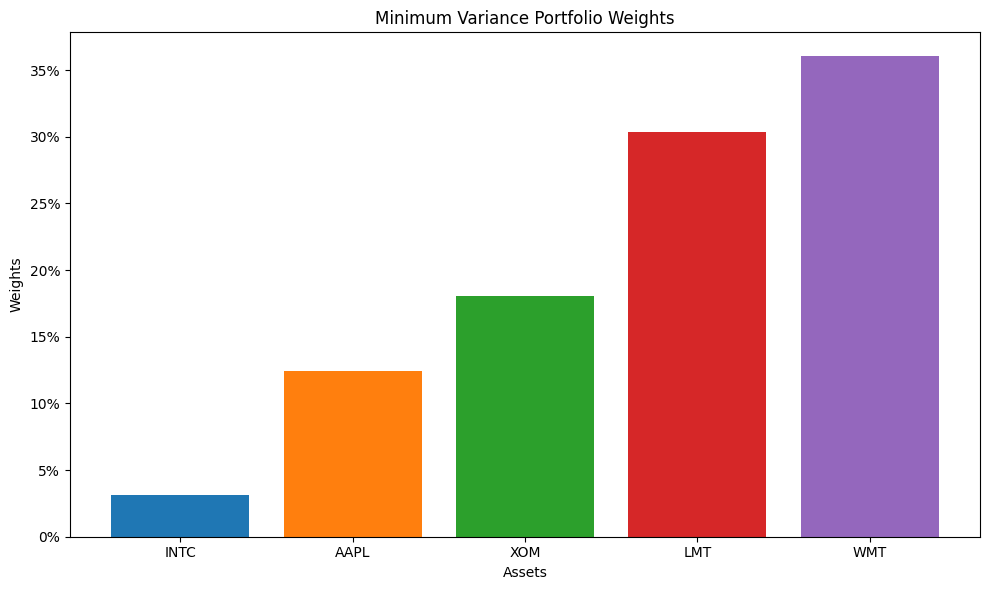

In [24]:
weights_min_var = min_var[tick].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(weights_min_var.index, weights_min_var.values, color=plt.cm.tab10.colors)
ax.set_xlabel("Assets")
ax.set_ylabel("Weights")
ax.set_title("Minimum Variance Portfolio Weights")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.tight_layout()
plt.show()

## 🎯 El Portfolio de Tangencia

El **Portfolio de Tangencia** es aquel que presenta el mayor Sharpe Ratio entre todos los portafolios simulados.

Como el Sharpe Ratio de cada portafolio está almacenado en la columna `SharpeRatio` de `portfolio_values`, utilizamos el método `.idxmax()` para identificar la fila que contiene el valor máximo:

```python
max_sr = portfolio_values.loc[portfolio_values['SharpeRatio'].idxmax()]
max_sr
```

La expresión:

```python
portfolio_values['SharpeRatio'].idxmax()
```

devuelve el índice del portafolio con el mayor Sharpe Ratio.

Luego:

```python
portfolio_values.loc[...]
```

extrae la fila completa correspondiente a ese portafolio.

Por lo tanto, el objeto `max_sr` contiene:

* el retorno anualizado del portafolio;
* su riesgo anualizado;
* su Sharpe Ratio;
* las ponderaciones asignadas a cada activo.

En términos formales, el Portfolio de Tangencia busca maximizar:

$$\max_{W}:\frac{E\left[\widetilde{r}_{p}\right]-r_{f}}{\sigma_{p}}$$

sujeto a:

$$\sum_{i=1}^{N}w_{i}=1$$

En este ejercicio no resolvemos directamente el problema de optimización. En cambio, seleccionamos el portafolio con el mayor Sharpe Ratio dentro del conjunto de combinaciones aleatorias generadas.

> 💡 El Portfolio de Tangencia ofrece la mejor relación entre exceso de retorno y riesgo entre todos los portafolios simulados.

In [25]:
max_sr = portfolio_values.loc[portfolio_values['SharpeRatio'].idxmax()]
max_sr

AAPL           0.072617
WMT            0.457669
INTC           0.002745
XOM            0.461205
LMT            0.005764
Return         0.236406
Risk           0.174615
SharpeRatio    1.092148
Name: 82519, dtype: float64

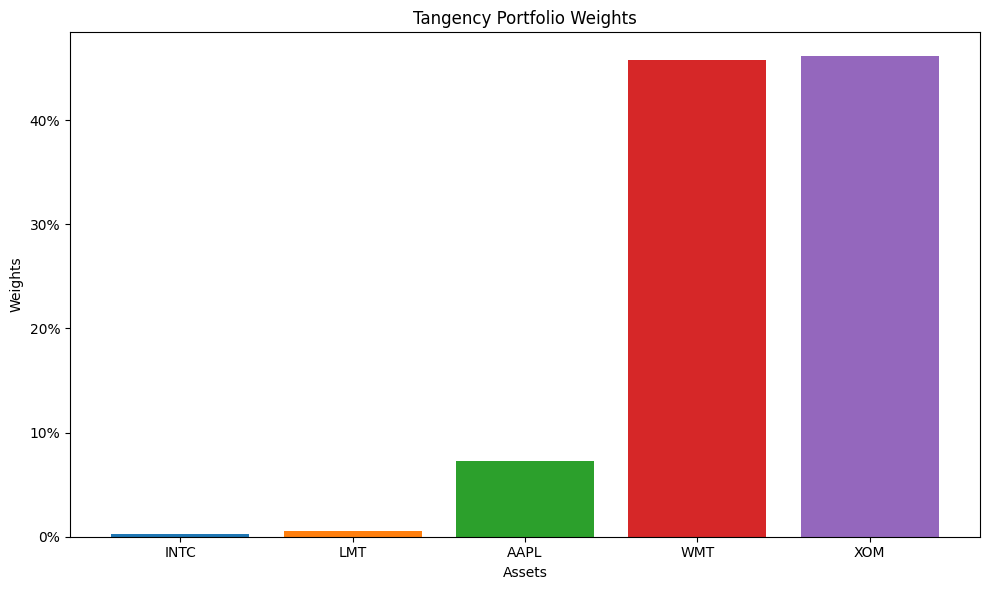

In [26]:
weights_max_sr = max_sr[tick].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(weights_max_sr.index, weights_max_sr.values, color=plt.cm.tab10.colors)
ax.set_xlabel("Assets")
ax.set_ylabel("Weights")
ax.set_title("Tangency Portfolio Weights")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.tight_layout()
plt.show()

## 📉 La Frontera Eficiente

Una vez simulados los portafolios y calculados sus retornos, riesgos y Sharpe Ratios, podemos representarlos gráficamente en el espacio riesgo-retorno.

Cada punto del gráfico corresponde a un portafolio diferente:

* el eje horizontal muestra el riesgo anualizado;
* el eje vertical muestra el retorno anualizado;
* el color de cada punto representa su Sharpe Ratio.

Además, destacaremos dos portafolios relevantes:

* el portafolio de mínima varianza, identificado por `min_var`;
* el Portfolio de Tangencia, identificado por `max_sr`.

La nube de puntos representa el conjunto de oportunidades de inversión obtenido mediante la simulación.

La **Frontera Eficiente** corresponde al borde superior izquierdo de esta nube. Está formada por los portafolios que ofrecen el mayor retorno posible para cada nivel de riesgo.

Un portafolio ubicado por debajo de la frontera es ineficiente, porque existe al menos otro portafolio que ofrece:

* un mayor retorno para el mismo nivel de riesgo; o
* un menor riesgo para el mismo nivel de retorno.

El punto negro identifica el portafolio de mínima varianza, mientras que el punto rojo identifica el Portfolio de Tangencia, es decir, aquel que presenta el mayor Sharpe Ratio entre todos los portafolios simulados.

> 💡 En este ejercicio, la frontera eficiente se aproxima mediante una simulación de portafolios aleatorios. Al aumentar el número de portafolios simulados, la forma de la frontera se vuelve más definida.

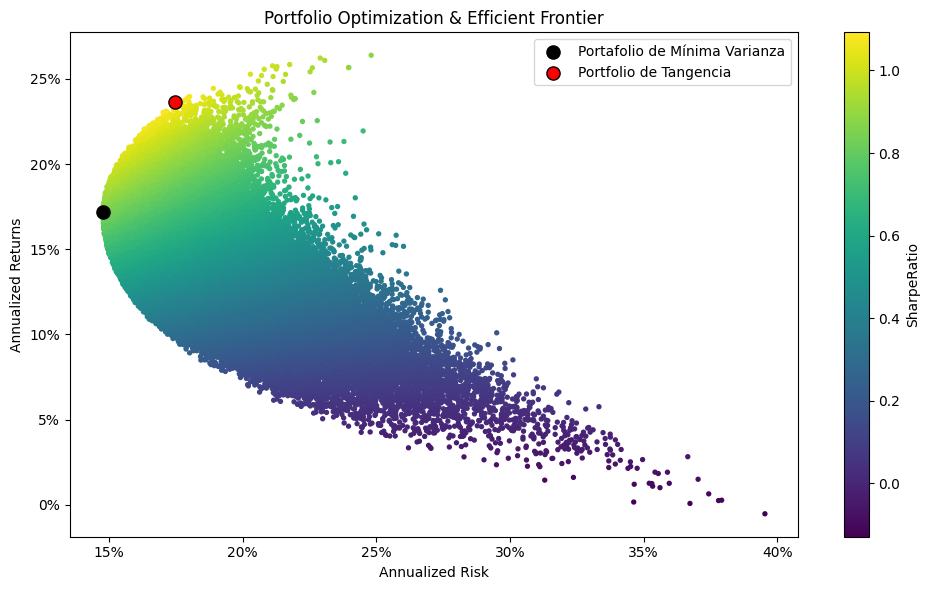

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(portfolio_values['Risk'], portfolio_values['Return'],
                c=portfolio_values['SharpeRatio'], cmap='viridis', s=8)
fig.colorbar(sc, ax=ax, label='SharpeRatio')

ax.scatter(min_var['Risk'], min_var['Return'], facecolor='black', edgecolor='black',
           s=90, zorder=3, label='Portafolio de Mínima Varianza')
ax.scatter(max_sr['Risk'], max_sr['Return'], facecolor='red', edgecolor='black',
           s=90, zorder=3, label='Portfolio de Tangencia')

ax.xaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.set_xlabel('Annualized Risk')
ax.set_ylabel('Annualized Returns')
ax.set_title('Portfolio Optimization & Efficient Frontier')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Y si lo queremos grabar:

In [28]:
# fig.savefig("Frontera_Ef.png", dpi=150)

---

# 🎯 Selección de Portfolio: Solo Activos Riesgosos

Hasta ahora hemos identificado dos portafolios de referencia sobre la Frontera Eficiente: el de **mínima varianza** y el de **tangencia**. Sin embargo, el portafolio que un inversionista debería elegir en la práctica depende de su propia tolerancia al riesgo.

Consideremos un individuo con una función de utilidad de tipo **media-varianza**, definida sobre el retorno esperado y el riesgo del portafolio, de la forma:

$$U\left(E\left[\widetilde{r}_{p}\right],\sigma_{p}\right)=E\left[\widetilde{r}_{p}\right]-\frac{A}{2}\sigma_{p}^{2}$$

donde:

* $E\left[\widetilde{r}_{p}\right]$ es el retorno esperado anualizado del portafolio;
* $\sigma_{p}$ es el riesgo (desviación estándar) anualizado del portafolio;
* $A$ es el **coeficiente de aversión al riesgo** del inversionista.

Tanto $E\left[\widetilde{r}_{p}\right]$ como $\sigma_{p}$ dependen de las ponderaciones $w_{i}$ elegidas por el inversionista —las verdaderas **variables de decisión** de este problema, que no deben confundirse con la riqueza del inversionista—.

Esta función de utilidad penaliza la varianza del portafolio, y la magnitud de esa penalización depende de $A$:

* un valor de $A$ más **alto** describe a un inversionista más averso al riesgo (**defensivo**): penaliza fuertemente la varianza y prefiere portafolios de menor riesgo;
* un valor de $A$ más **bajo** describe a un inversionista más tolerante al riesgo (**agresivo**): penaliza poco la varianza y prefiere portafolios de mayor riesgo y retorno esperado;
* valores intermedios de $A$ describen a un inversionista **moderado**.

El portafolio óptimo para un inversionista con un determinado valor de $A$ es, por definición, aquel —entre todos los simulados— cuyo vector de ponderaciones $W$ **maximiza** $U\left(E\left[\widetilde{r}_{p}\right],\sigma_{p}\right)$.

### ¿Qué valores de $A$ utilizar?

No existe un valor "correcto" de $A$: en la práctica se estima mediante encuestas de tolerancia al riesgo, o se calibra según el horizonte de inversión y los objetivos del inversionista. Para ilustrar tres perfiles claramente diferenciados, probamos numéricamente distintos valores de $A$ sobre nuestros portafolios simulados y observamos cuál maximiza la utilidad en cada caso:

| Perfil        |  $A$ | Portafolio resultante                                          |
| ------------- | ---: | --------------------------------------------------------------- |
| 🚀 Agresivo   |    3 | Algo más riesgoso y con mayor retorno que el Portfolio de Tangencia, sin llegar al extremo superior de la frontera. |
| ⚖️ Moderado   |    6 | Prácticamente coincide con el Portfolio de Tangencia (máximo Sharpe Ratio). |
| 🛡️ Defensivo  |   12 | Más cercano al extremo de menor riesgo de la frontera, sin llegar a ser el de mínima varianza. |

<div style="margin-top: 2em;"></div>

> ⚠️ **Cuidado con la interpretación:** en esta sección **no** estamos combinando el portafolio con el activo libre de riesgo — el inversionista invierte el 100% de su riqueza en activos riesgosos, y distintos valores de $A$ seleccionan, en general, **puntos distintos** a lo largo de toda la frontera eficiente. Que el portafolio con $A=6$ resulte tan cercano al de tangencia es una coincidencia numérica de estos datos particulares (y, en parte, de la resolución discreta de la simulación de Monte Carlo), no una consecuencia teórica de este ejercicio.

In [29]:
# Perfiles de aversión al riesgo a evaluar
perfiles = pd.DataFrame({
    'Perfil': ['Agresivo', 'Moderado', 'Defensivo'],
    'A': [3, 6, 12],
})

filas = []
for _, fila in perfiles.iterrows():
    A = fila['A']
    utilidad = portfolio_values['Return'] - (A / 2) * (portfolio_values['Risk']**2)
    optimo = portfolio_values.loc[utilidad.idxmax()].copy()
    optimo['Perfil'] = fila['Perfil']
    optimo['A'] = A
    filas.append(optimo)

optimal_portfolios = pd.DataFrame(filas).reset_index(drop=True)
optimal_portfolios['Perfil'] = pd.Categorical(optimal_portfolios['Perfil'], categories=perfiles['Perfil'], ordered=True)

# Etiqueta para la leyenda del gráfico, con el valor de A y el Sharpe Ratio de cada perfil.
# Se construye a partir de los valores calculados (no quedan fijos), por lo que
# se actualiza automáticamente si el notebook se vuelve a ejecutar con datos nuevos.
optimal_portfolios['Etiqueta'] = optimal_portfolios.apply(
    lambda r: f"{r['Perfil']} (A={r['A']:g}, SR={r['SharpeRatio']:.3f})", axis=1)

colores_perfil = {'Agresivo': '#d62728', 'Moderado': '#ff7f0e', 'Defensivo': '#2ca02c'}

tabla = optimal_portfolios[['Perfil', 'A', 'Return', 'Risk', 'SharpeRatio']].copy()
tabla['Return'] = (tabla['Return'] * 100).round(2)
tabla['Risk'] = (tabla['Risk'] * 100).round(2)
tabla['SharpeRatio'] = tabla['SharpeRatio'].round(3)
tabla = tabla.rename(columns={'Return': 'Retorno Anual (%)', 'Risk': 'Riesgo Anual (%)', 'SharpeRatio': 'Sharpe Ratio'})
tabla.style.format({'Retorno Anual (%)': '{:.2f}', 'Riesgo Anual (%)': '{:.2f}', 'Sharpe Ratio': '{:.3f}'}).hide(axis='index')

Perfil,A,Retorno Anual (%),Riesgo Anual (%),Sharpe Ratio
Agresivo,3,23.96,18.01,1.077
Moderado,6,23.64,17.46,1.092
Defensivo,12,20.99,15.74,1.043


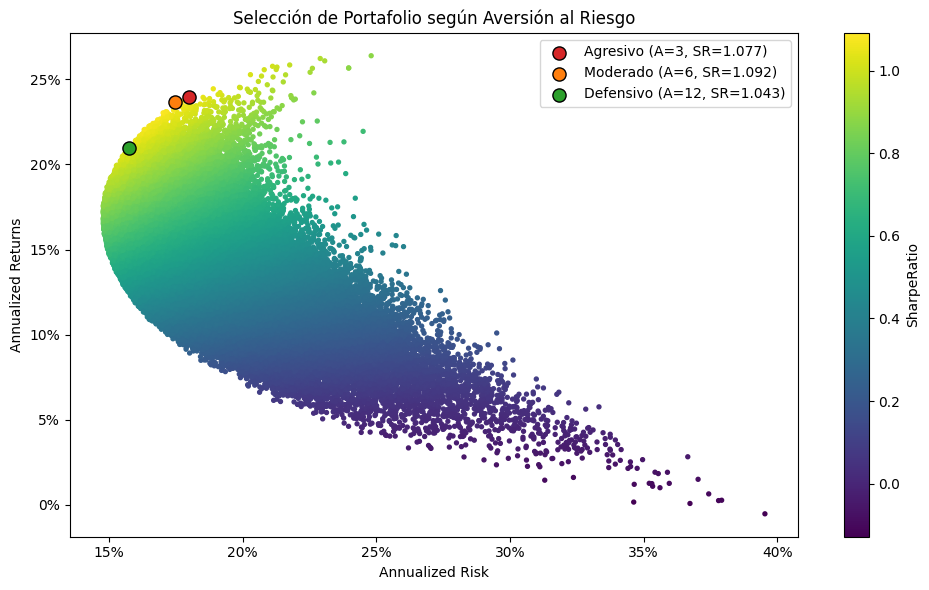

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(portfolio_values['Risk'], portfolio_values['Return'],
                c=portfolio_values['SharpeRatio'], cmap='viridis', s=8)
fig.colorbar(sc, ax=ax, label='SharpeRatio')

for _, fila in optimal_portfolios.iterrows():
    ax.scatter(fila['Risk'], fila['Return'], facecolor=colores_perfil[fila['Perfil']],
               edgecolor='black', s=90, zorder=3, label=fila['Etiqueta'])

ax.xaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.set_xlabel('Annualized Risk')
ax.set_ylabel('Annualized Returns')
ax.set_title('Selección de Portafolio según Aversión al Riesgo')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---

# 🎯 Capital Allocation Line (CAL): Activos Riesgosos + Activo Libre de Riesgo

Hasta ahora hemos restringido el análisis a portafolios compuestos **únicamente por activos riesgosos**. Introduzcamos ahora la posibilidad de combinar cualquier portafolio riesgoso $P$ con el **activo libre de riesgo**.

Sea $y$ la proporción de la riqueza invertida en el portafolio riesgoso $P$, y $(1-y)$ la proporción invertida en el activo libre de riesgo. El retorno del portafolio combinado $C$ es, entonces:

$$\widetilde{r}_{C}=y\,\widetilde{r}_{P}+(1-y)\,r_{f}$$

Tomando esperanza a ambos lados y reordenando términos:

$$E\left[\widetilde{r}_{C}\right]=y\,E\left[\widetilde{r}_{P}\right]+(1-y)\,r_{f}=r_{f}+y\left(E\left[\widetilde{r}_{P}\right]-r_{f}\right)$$

Análogamente, dado que el activo libre de riesgo no tiene incertidumbre, el riesgo del portafolio combinado es simplemente:

$$\sigma_{C}=y\,\sigma_{P}$$

Estas dos ecuaciones describen una **línea recta** en el espacio riesgo-retorno: parte en el punto $(0,\,r_{f})$ —invertir el 100% en el activo libre de riesgo— y pasa por $(\sigma_{P},\,E[\widetilde{r}_{P}])$ cuando $y=1$ —invertir el 100% en el portafolio riesgoso $P$—. Valores $y>1$ representan **apalancamiento**: pedir prestado al activo libre de riesgo para invertir más del 100% de la riqueza en $P$.

Esta recta se conoce como la **Línea de Asignación de Capital** (*Capital Allocation Line*, CAL) del portafolio $P$. Su pendiente es:

$$\text{Pendiente}=\frac{E\left[\widetilde{r}_{P}\right]-r_{f}}{\sigma_{P}}=SR_{P}$$

Es decir, **la pendiente de la CAL es exactamente el Sharpe Ratio del portafolio $P$**: mientras más inclinada sea la línea, mayor es el retorno adicional obtenido por cada unidad de riesgo asumida.

### ¿Qué ocurre si elegimos distintos portafolios $P$?

Tracemos la CAL para tres portafolios riesgosos distintos:

* el Portfolio de Tangencia (máximo Sharpe Ratio entre todos los simulados);
* el portafolio de **mínima varianza**;
* un portafolio **"típico"**: aquel cuyo Sharpe Ratio es el más cercano a la mediana de todos los portafolios simulados, sin ninguna propiedad especial.

Como la pendiente de cada CAL es el Sharpe Ratio del portafolio elegido, la línea con mayor pendiente será, por construcción, la que se dirige hacia el Portfolio de Tangencia.

La siguiente celda selecciona tres portafolios de referencia (Tangencia, Mínima Varianza y Típico), calcula los puntos de sus respectivas Líneas de Asignación de Capital (CAL), y muestra una tabla con su retorno, riesgo y Sharpe Ratio.

In [31]:
# Portafolio "típico": el más cercano a la mediana del Sharpe Ratio simulado
mediana_sr = portfolio_values['SharpeRatio'].median()
tipico = portfolio_values.loc[(portfolio_values['SharpeRatio'] - mediana_sr).abs().idxmin()]

anchor_portfolios = pd.DataFrame([
    {**max_sr.to_dict(), 'Linea': 'Tangencia'},
    {**min_var.to_dict(), 'Linea': 'Mínima Varianza'},
    {**tipico.to_dict(), 'Linea': 'Típico (mediana)'},
])
anchor_portfolios['SR_linea'] = (anchor_portfolios['Return'] - rf) / anchor_portfolios['Risk']

# Cada CAL: parte en (0, rf) [y = 0] y se extiende un 15% más allá
# del portafolio riesgoso puro [y = 1.15], representando apalancamiento
filas = []
for _, fila in anchor_portfolios.iterrows():
    for y in [0, 1.15]:
        filas.append({
            'Linea': fila['Linea'],
            'SR_linea': fila['SR_linea'],
            'y': y,
            'Risk_linea': y * fila['Risk'],
            'Return_linea': rf + y * (fila['Return'] - rf),
        })
cal_lines = pd.DataFrame(filas)
cal_lines['Etiqueta'] = cal_lines.apply(lambda r: f"{r['Linea']} (SR={r['SR_linea']:.3f})", axis=1)

tabla = anchor_portfolios[['Linea', 'Return', 'Risk', 'SR_linea']].copy()
tabla['Return'] = (tabla['Return'] * 100).round(2)
tabla['Risk'] = (tabla['Risk'] * 100).round(2)
tabla['SR_linea'] = tabla['SR_linea'].round(3)
tabla = tabla.rename(columns={'Linea': 'Línea', 'Return': 'Retorno Anual (%)',
                               'Risk': 'Riesgo Anual (%)', 'SR_linea': 'Sharpe Ratio'})
tabla.style.format({'Retorno Anual (%)': '{:.2f}', 'Riesgo Anual (%)': '{:.2f}', 'Sharpe Ratio': '{:.3f}'}).hide(axis='index')

Línea,Retorno Anual (%),Riesgo Anual (%),Sharpe Ratio
Tangencia,23.64,17.46,1.092
Mínima Varianza,17.22,14.78,0.856
Típico (mediana),13.16,16.62,0.517


Como la pendiente de una CAL es exactamente el Sharpe Ratio del portafolio que la genera, construir las tres CAL en los mismos ejes nos deja **leer geométricamente** cuál tiene la pendiente más pronunciada. La tabla confirma numéricamente lo que veremos en el gráfico: el portafolio de tangencia tiene el mayor Sharpe Ratio de los tres.

La siguiente celda grafica las tres CAL junto a la nube de portafolios simulados, marcando los puntos de los tres portafolios de referencia y el del activo libre de riesgo.

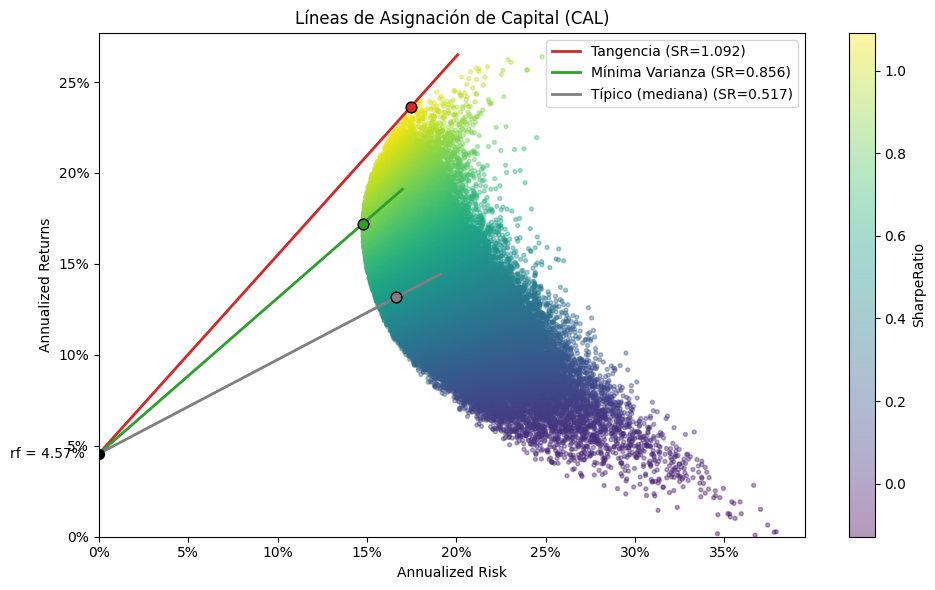

In [32]:
colores_linea = {'Tangencia': '#d62728', 'Mínima Varianza': '#2ca02c', 'Típico (mediana)': '#7f7f7f'}

y_top = portfolio_values['Return'].max()
x_max = portfolio_values['Risk'].max()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(portfolio_values['Risk'], portfolio_values['Return'],
                c=portfolio_values['SharpeRatio'], cmap='viridis', s=8, alpha=0.4)
fig.colorbar(sc, ax=ax, label='SharpeRatio')

for linea, grupo in cal_lines.groupby('Linea', sort=False):
    color = colores_linea[linea]
    etiqueta = grupo['Etiqueta'].iloc[0]
    ax.plot(grupo['Risk_linea'], grupo['Return_linea'], color=color, linewidth=2, label=etiqueta)

for _, fila in anchor_portfolios.iterrows():
    ax.scatter(fila['Risk'], fila['Return'], color=colores_linea[fila['Linea']],
               edgecolor='black', s=60, zorder=3)

ax.scatter(0, rf, color='black', s=50, zorder=3)
ax.annotate(f"rf = {rf*100:.2f}%", xy=(0, rf), xytext=(-x_max*0.02, rf),
            ha='right', va='center', fontsize=10)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_top * 1.05)
ax.xaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.set_xlabel('Annualized Risk')
ax.set_ylabel('Annualized Returns')
ax.set_title('Líneas de Asignación de Capital (CAL)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

El gráfico confirma visualmente lo que ya anticipaban las pendientes: la CAL hacia el Portfolio de Tangencia queda por encima de las otras dos en todo el rango de riesgo, ofreciendo mayor retorno esperado para cualquier nivel de riesgo — es decir, **domina** a las demás.

### ⭐ ¿Por qué la CAL hacia el Portfolio de Tangencia es óptima?

En el gráfico anterior, la línea hacia el Portfolio de Tangencia (roja) es, por construcción, la más inclinada de todas las CAL posibles: **ninguna otra combinación entre el activo libre de riesgo y un portafolio riesgoso ofrece un mayor retorno para un mismo nivel de riesgo** (o, equivalentemente, un menor riesgo para un mismo nivel de retorno).

Esto tiene una consecuencia muy fuerte: **todo inversionista racional, sin importar su grado de aversión al riesgo, debería mantener el Portfolio de Tangencia como su única componente riesgosa**. Un inversionista agresivo simplemente invertirá una mayor proporción $y$ de su riqueza en dicho portafolio (incluso apalancándose, con $y>1$), mientras que un inversionista defensivo invertirá una proporción menor, prestando el resto al activo libre de riesgo ($y<1$). Pero en ambos casos, **la composición de la parte riesgosa de su cartera es exactamente la misma**: los pesos del Portfolio de Tangencia.

Este resultado se conoce como el **Teorema de Separación de Tobin** (o *de los dos fondos*): la decisión de **qué** portafolio riesgoso mantener (siempre el de tangencia) es independiente de la decisión de **cuánto** invertir en él (que sí depende de $A$).

> ⚠️ Note que esta es la misma pregunta que abordamos en la sección anterior ("Selección de Portfolio: Solo Activos Riesgosos"), pero con una respuesta radicalmente distinta: allí, sin activo libre de riesgo, cada valor de $A$ seleccionaba un portafolio **distinto** a lo largo de la frontera. Aquí, con un activo libre de riesgo disponible, todos los inversionistas coinciden en el **mismo** portafolio riesgoso.

Por su rol central —la CAL óptima, la que todo inversionista debería utilizar—, la línea hacia el Portfolio de Tangencia recibe un nombre propio: la **Línea de Mercado de Capitales** (*Capital Market Line*, CML).

## 🧭 Frontera Eficiente: La Línea de Mercado de Capitales o Capital Market Line (CML)

Con esto podemos responder una pregunta más profunda: ¿cuál es, en definitiva, la Frontera Eficiente?

* **Sin activo libre de riesgo**, la Frontera Eficiente es la curva de Markowitz: el borde superior del conjunto de portafolios riesgosos factibles, calculado en la sección "Selección de Portfolio: Solo Activos Riesgosos".
* **Con un activo libre de riesgo disponible**, el conjunto de oportunidades se amplía: ahora podemos alcanzar cualquier punto sobre la CML, no solo los puntos sobre la curva riesgosa. Como la CML domina a la curva de Markowitz en **todo** punto —excepto en el propio Portfolio de Tangencia, donde ambas coinciden—, ya no tiene sentido conformarse con un portafolio ubicado sobre la curva.

Por lo tanto, una vez que incorporamos el activo libre de riesgo, **la verdadera Frontera Eficiente deja de ser la curva y pasa a ser la CML**: una línea recta que parte en $r_f$ y es tangente a la frontera riesgosa en el Portfolio de Tangencia. La curva de Markowitz no desaparece —sigue delimitando lo que es alcanzable usando *solo* activos riesgosos—, pero deja de ser la frontera relevante para un inversionista que sí tiene acceso a un activo libre de riesgo.

> 💡 **En síntesis:** la Frontera Eficiente "verdadera" es la CML. Cada inversionista elige su punto sobre ella —es decir, su combinación entre el activo libre de riesgo y el Portfolio de Tangencia— de acuerdo con su propio coeficiente de aversión al riesgo $A$, tal como vimos para el caso de un solo activo riesgoso.

---

# 🎯 Selección de Portfolio: Activos Riesgosos + Activo Libre de Riesgo

Retomemos el ejercicio de la sección "Selección de Portfolio: Solo Activos Riesgosos", pero incorporando ahora el activo libre de riesgo. Como vimos, todo inversionista debería mantener el **Portfolio de Tangencia** como su única componente riesgosa, ajustando únicamente $y$ —la proporción de su riqueza invertida en él— de acuerdo con su aversión al riesgo $A$.

El portafolio combinado $C$ tiene utilidad:

$$U\left(E\left[\widetilde{r}_{C}\right],\sigma_{C}\right)=E\left[\widetilde{r}_{C}\right]-\frac{A}{2}\sigma_{C}^{2}=r_{f}+y\left(E\left[\widetilde{r}_{P}\right]-r_{f}\right)-\frac{A}{2}y^{2}\sigma_{P}^{2}$$

donde $P$ es, en este caso, el Portfolio de Tangencia. Derivando respecto de $y$ e igualando a cero, obtenemos la asignación óptima:

$$y^{*}=\frac{E\left[\widetilde{r}_{P}\right]-r_{f}}{A\,\sigma_{P}^{2}}$$

A diferencia de la sección "Selección de Portfolio: Solo Activos Riesgosos" —donde cada valor de $A$ debía buscarse **numéricamente** entre miles de portafolios simulados—, aquí $y^{*}$ se obtiene de forma **cerrada**, sin necesidad de simular nada: basta con conocer el retorno y riesgo del Portfolio de Tangencia y la tasa libre de riesgo.

> ⚠️ Los valores de $A$ que usaremos en esta sección **no son los mismos** que en la sección "Selección de Portfolio: Solo Activos Riesgosos". Allí, $A$ determinaba la elección entre miles de portafolios simulados a lo largo de la frontera curva; aquí, $A$ determina directamente cuánto apalancarse o prestar en torno a un único portafolio fijo (el de tangencia), por lo que la escala relevante de $A$ es distinta.

### ¿Qué valores de $A$ utilizar ahora?

Nuevamente probamos numéricamente varios valores de $A$ en la fórmula de $y^{*}$ y elegimos tres que ilustran perfiles claramente diferenciados:

| Perfil        | $A$ | $y^{*}$ (aprox.)                          |
| ------------- | --: | ------------------------------------------ |
| 🚀 Agresivo   |   3 | $y^{*}>1$: se apalanca, pidiendo prestado al activo libre de riesgo para invertir más del 100% en el Portfolio de Tangencia. |
| ⚖️ Moderado   |   6 | $y^{*}\approx 1$: invierte prácticamente toda su riqueza en el Portfolio de Tangencia, sin apalancarse ni prestar. |
| 🛡️ Defensivo  |  12 | $y^{*}<1$: invierte solo una fracción de su riqueza en el Portfolio de Tangencia, prestando el resto al activo libre de riesgo. |

<div style="margin-top: 2em;"></div>

> 💡 A diferencia del ejercicio anterior, **los tres perfiles ahora comparten exactamente el mismo portafolio riesgoso** —el de tangencia—. La única diferencia entre ellos es *cuánto* invierten en él.

La siguiente celda calcula la asignación óptima $y^{*}$ al Portfolio de Tangencia para cada perfil de aversión al riesgo, y muestra una tabla con el resultado.

In [33]:
# Asignación óptima y* para cada perfil de aversión al riesgo,
# usando el Portfolio de Tangencia como único activo riesgoso
perfiles_y = pd.DataFrame({'Perfil': ['Agresivo', 'Moderado', 'Defensivo'], 'A': [3, 6, 12]})

tang = anchor_portfolios.loc[anchor_portfolios['Linea'] == 'Tangencia'].iloc[0]

optimal_y = perfiles_y.copy()
optimal_y['y'] = (tang['Return'] - rf) / (optimal_y['A'] * tang['Risk']**2)
optimal_y['Return_C'] = rf + optimal_y['y'] * (tang['Return'] - rf)
optimal_y['Risk_C'] = optimal_y['y'] * tang['Risk']
optimal_y['SharpeRatio_C'] = (optimal_y['Return_C'] - rf) / optimal_y['Risk_C']
optimal_y['Perfil'] = pd.Categorical(optimal_y['Perfil'], categories=perfiles_y['Perfil'], ordered=True)
optimal_y['Etiqueta'] = optimal_y.apply(lambda r: f"{r['Perfil']} (y={r['y']:.2f})", axis=1)

tabla = optimal_y[['Perfil', 'A', 'y', 'Return_C', 'Risk_C', 'SharpeRatio_C']].copy()
tabla['y'] = tabla['y'].round(3)
tabla['Return_C'] = (tabla['Return_C'] * 100).round(2)
tabla['Risk_C'] = (tabla['Risk_C'] * 100).round(2)
tabla['SharpeRatio_C'] = tabla['SharpeRatio_C'].round(3)
tabla = tabla.rename(columns={'y': 'y* (proporción en Tangencia)', 'Return_C': 'Retorno Anual (%)',
                               'Risk_C': 'Riesgo Anual (%)', 'SharpeRatio_C': 'Sharpe Ratio'})
tabla.style.format({'y* (proporción en Tangencia)': '{:.3f}', 'Retorno Anual (%)': '{:.2f}',
                     'Riesgo Anual (%)': '{:.2f}', 'Sharpe Ratio': '{:.3f}'}).hide(axis='index')

Perfil,A,y* (proporción en Tangencia),Retorno Anual (%),Riesgo Anual (%),Sharpe Ratio
Agresivo,3,2.085,44.33,36.40,1.092
Moderado,6,1.042,24.45,18.20,1.092
Defensivo,12,0.521,14.51,9.10,1.092


La siguiente celda grafica los tres puntos óptimos sobre la Línea de Mercado de Capitales (CML), junto con la nube de portafolios simulados y el activo libre de riesgo.

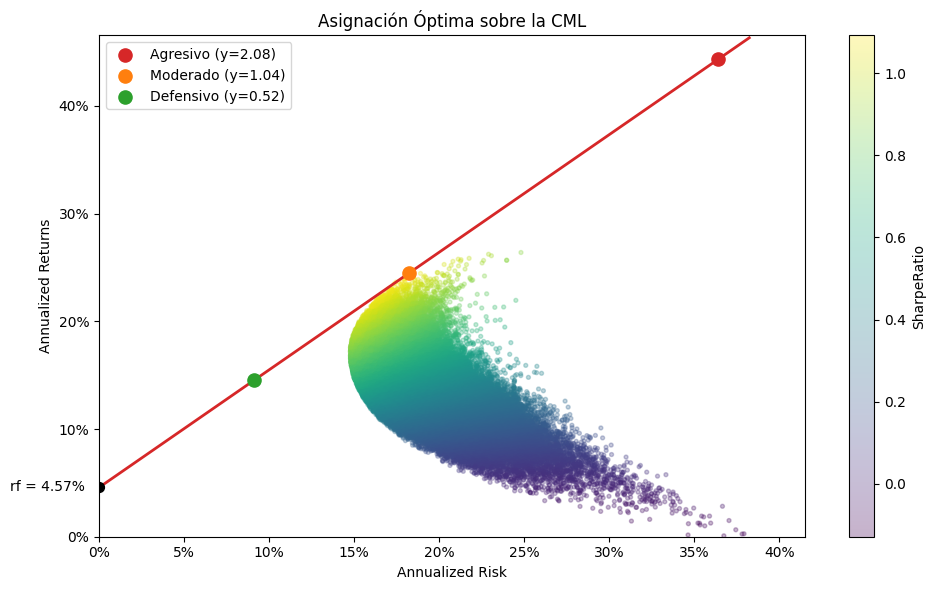

In [34]:
colores_perfil2 = {'Agresivo': '#d62728', 'Moderado': '#ff7f0e', 'Defensivo': '#2ca02c'}

# La CML se extiende lo suficiente para cubrir al inversionista más apalancado
y_max_needed = optimal_y['y'].max() * 1.05
cml_line = pd.DataFrame({'y': [0, y_max_needed]})
cml_line['Risk_linea'] = cml_line['y'] * tang['Risk']
cml_line['Return_linea'] = rf + cml_line['y'] * (tang['Return'] - rf)

y_top = max(optimal_y['Return_C'].max(), portfolio_values['Return'].max()) * 1.05
x_max = max(optimal_y['Risk_C'].max(), portfolio_values['Risk'].max()) * 1.05

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(portfolio_values['Risk'], portfolio_values['Return'],
                c=portfolio_values['SharpeRatio'], cmap='viridis', s=8, alpha=0.3)
fig.colorbar(sc, ax=ax, label='SharpeRatio')

ax.plot(cml_line['Risk_linea'], cml_line['Return_linea'], color='#d62728', linewidth=2)

for _, fila in optimal_y.iterrows():
    ax.scatter(fila['Risk_C'], fila['Return_C'], color=colores_perfil2[fila['Perfil']],
               s=90, zorder=3, label=fila['Etiqueta'])

ax.scatter(0, rf, color='black', s=50, zorder=3)
ax.annotate(f"rf = {rf*100:.2f}%", xy=(0, rf), xytext=(-x_max*0.02, rf),
            ha='right', va='center', fontsize=10)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_top)
ax.xaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
ax.set_xlabel('Annualized Risk')
ax.set_ylabel('Annualized Returns')
ax.set_title('Asignación Óptima sobre la CML')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 🧭 Conclusión

Los tres puntos —agresivo, moderado y defensivo— caen exactamente **sobre la misma recta**: la CML. Esto es precisamente lo que predice el Teorema de Separación de Tobin: la composición del portafolio riesgoso (el de tangencia) es la misma para todos los inversionistas, y solo cambia la proporción $y$ invertida en él —incluyendo, cuando $y>1$, el uso de apalancamiento—.

Esto contrasta con el resultado de la sección "Selección de Portfolio: Solo Activos Riesgosos", donde cada perfil de riesgo terminaba en un portafolio riesgoso **distinto**, a lo largo de la curva de Markowitz. La diferencia entre ambos ejercicios ilustra, en definitiva, el efecto de incorporar un activo libre de riesgo a la selección de portafolio.

---

## 📋 Tabla resumen: los tres perfiles, con y sin activo libre de riesgo

Para cerrar, comparemos directamente los resultados de ambos ejercicios —**Solo Activos Riesgosos** y **Activos Riesgosos + Activo Libre de Riesgo**— para los mismos tres perfiles de aversión al riesgo ($A=3,6,12$).

In [35]:
tabla_izq = optimal_portfolios[['Perfil', 'A', 'Return', 'Risk', 'SharpeRatio']].copy()
tabla_izq['Return'] = (tabla_izq['Return'] * 100).round(2)
tabla_izq['Risk'] = (tabla_izq['Risk'] * 100).round(2)
tabla_izq['SharpeRatio'] = tabla_izq['SharpeRatio'].round(3)
tabla_izq = tabla_izq.rename(columns={'Return': 'Retorno (%)', 'Risk': 'Riesgo (%)', 'SharpeRatio': 'Sharpe Ratio'})

tabla_der = optimal_y[['Return_C', 'Risk_C', 'SharpeRatio_C']].copy()
tabla_der['Return_C'] = (tabla_der['Return_C'] * 100).round(2)
tabla_der['Risk_C'] = (tabla_der['Risk_C'] * 100).round(2)
tabla_der['SharpeRatio_C'] = tabla_der['SharpeRatio_C'].round(3)
tabla_der = tabla_der.rename(columns={'Return_C': 'Retorno (%)', 'Risk_C': 'Riesgo (%)', 'SharpeRatio_C': 'Sharpe Ratio'})
tabla_der.index = tabla_izq.index

tabla_comparativa = pd.concat([tabla_izq, tabla_der], axis=1)
tabla_comparativa.columns = pd.MultiIndex.from_tuples(
    [(' ', 'Perfil'), (' ', 'A'),
     ('Solo Activos Riesgosos', 'Retorno (%)'),
     ('Solo Activos Riesgosos', 'Riesgo (%)'),
     ('Solo Activos Riesgosos', 'Sharpe Ratio'),
     ('Activos Riesgosos + Activo Libre de Riesgo', 'Retorno (%)'),
     ('Activos Riesgosos + Activo Libre de Riesgo', 'Riesgo (%)'),
     ('Activos Riesgosos + Activo Libre de Riesgo', 'Sharpe Ratio')]
)

fmt = {col: '{:.2f}' for col in tabla_comparativa.columns if col[1] in ('Retorno (%)', 'Riesgo (%)')}
fmt.update({col: '{:.3f}' for col in tabla_comparativa.columns if col[1] == 'Sharpe Ratio'})

tabla_comparativa.style.hide(axis='index').format(fmt).set_table_styles(
    [{'selector': 'th, td', 'props': [('text-align', 'center')]}]
)

> 💡 Nótese que el Sharpe Ratio del panel derecho es **idéntico** para los tres perfiles: al combinarse con el activo libre de riesgo, los tres inversionistas terminan sobre la misma CML, por lo que comparten la misma relación retorno-riesgo. En el panel izquierdo, en cambio, el Sharpe Ratio **varía** entre perfiles, ya que cada uno selecciona un portafolio riesgoso distinto a lo largo de la frontera curva.